# RD INFRO TECHNOLOGY - Data Science Internship

## Student Performance Analysis and Prediction

**Name:** Sanjana S

**Domain:** Data Science

**Dataset:** Student Performance Dataset

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

# Task 1: Business Problem Understanding

### Objective
The objective of this project is to analyze student academic performance and predict final grades based on demographic, social, and academic factors.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 2: Data Acquisition

### Dataset Source
Kaggle Student Performance Dataset

### Dataset Information
- 395 Student Records
- 33 Features
- Final Grade (G3) used as target variable

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Student Performance Dataset.csv to Student Performance Dataset.csv


In [4]:
import pandas as pd

df = pd.read_csv('Student Performance Dataset.csv')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Task 3: Data Preprocessing & Cleaning

### Tasks Performed

- Checked dataset shape
- Inspected column names
- Checked missing values
- Checked duplicate records
- Verified data types
- Generated statistical summary

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (395, 33)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [6]:
missing_values = df.isnull().sum()

print(missing_values)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [7]:
duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

Number of Duplicate Rows: 0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [9]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# Task 4: Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis was performed to understand student performance patterns and identify relationships between various factors affecting final grades.

## Visualizations Included

- Distribution of Final Grades
- Study Time vs Final Grade
- Absences vs Final Grade
- Correlation Heatmap

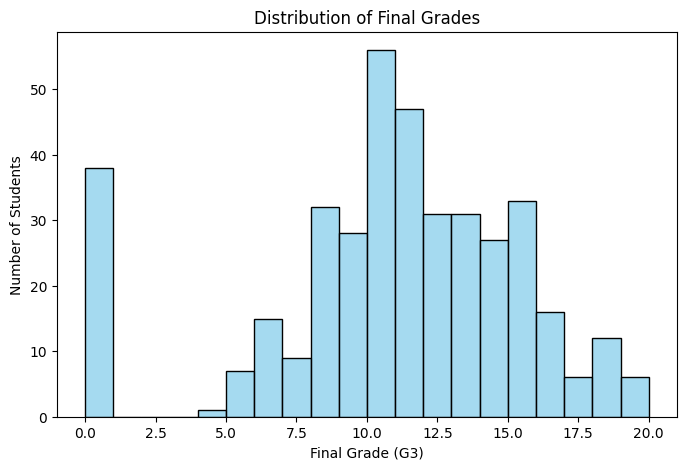

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, color='skyblue')

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

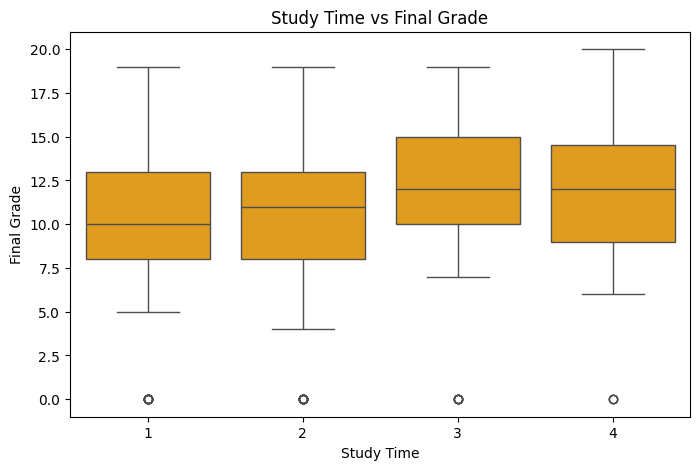

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x='studytime', y='G3', data=df, color='orange')

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")

plt.show()

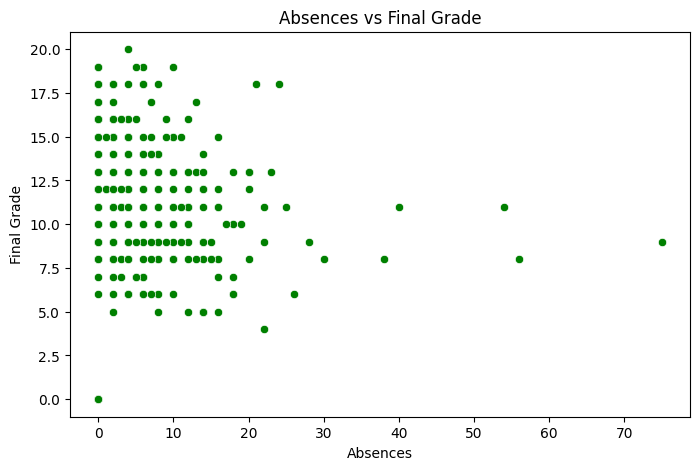

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='absences', y='G3', data=df, color='green')

plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")

plt.show()

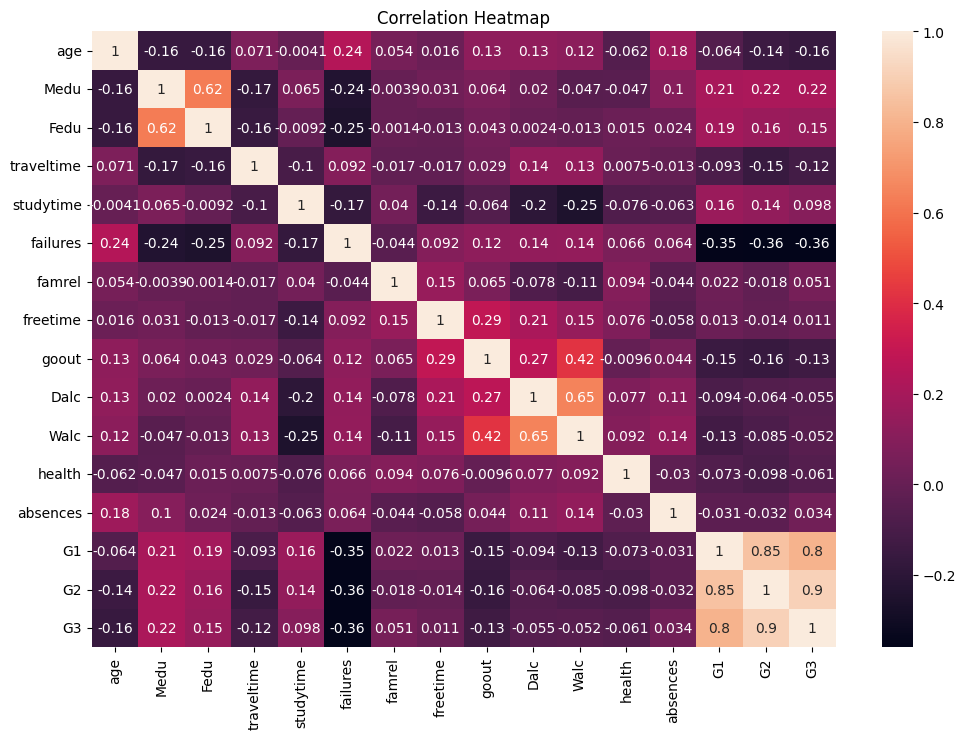

In [30]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

# Task 5: Feature Engineering

## Objective

Feature Engineering was performed to prepare the dataset for machine learning.

## Tasks Performed

- Converted categorical features into numerical format
- Applied Label Encoding to object-type columns
- Prepared features and target variables
- Created machine-learning-ready dataset

In [31]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

for col in df_ml.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


In [32]:
X = df_ml.drop('G3', axis=1)
y = df_ml['G3']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (395, 32)
Target Shape: (395,)


# Task 6: Model Building

## Objective

A machine learning model was developed to predict students' final grades based on academic, demographic, and social factors.

## Model Used

- Random Forest Regressor

## Steps Performed

- Split the dataset into training and testing sets
- Trained the Random Forest model
- Generated predictions on test data

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (316, 32)
Testing Data: (79, 32)


In [34]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [35]:
predictions = model.predict(X_test)

print(predictions[:10])

[ 8.08 11.62  6.62  9.79  9.11 12.78 18.69  6.68  6.58 13.35]


# Task 7: Model Evaluation

## Objective

The trained machine learning model was evaluated to measure its predictive performance and accuracy.

## Evaluation Metrics Used

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

## Purpose

These metrics help assess how accurately the model predicts students' final grades and determine the overall effectiveness of the Random Forest Regressor.

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.1050632911392408
Mean Squared Error (MSE): 3.4867417721518983
Root Mean Squared Error (RMSE): 1.867281920908543
R² Score: 0.8299569015097052


In [37]:
comparison = pd.DataFrame({
    'Actual Grade': y_test.values,
    'Predicted Grade': predictions
})

comparison.head(10)

,Actual Grade,Predicted Grade
0,10,8.08
1,12,11.62
2,5,6.62
3,10,9.79
4,9,9.11
5,13,12.78
6,18,18.69
7,6,6.68
8,0,6.58
9,14,13.35


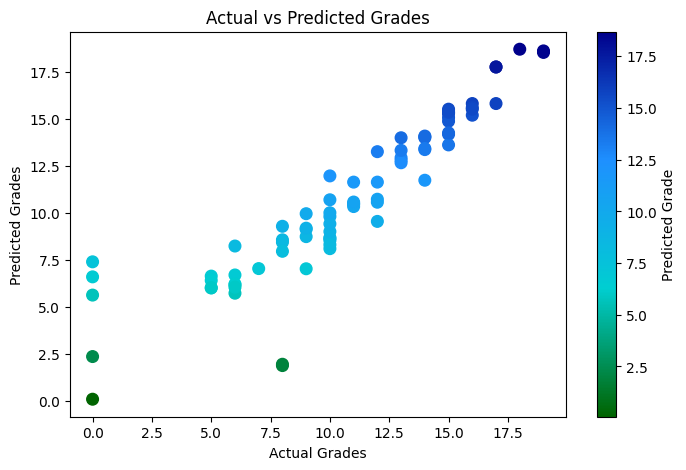

In [65]:
from matplotlib.colors import LinearSegmentedColormap

ocean_peacock = LinearSegmentedColormap.from_list(
    "ocean_peacock",
    [
        "#006400",  # Dark Green
        "#00CED1",  # Dark Turquoise
        "#1E90FF",  # Dodger Blue
        "#00008B"   # Dark Blue
    ]
)

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions,
    c=predictions,
    cmap=ocean_peacock,
    s=70
)

plt.colorbar(label='Predicted Grade')

plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Grades")

plt.show()

In [39]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
31,G2,0.792518
29,absences,0.110344
2,age,0.015196
10,reason,0.010257
30,G1,0.007557
23,famrel,0.006354
8,Mjob,0.006137
22,romantic,0.005654
28,health,0.004655
18,activities,0.004456


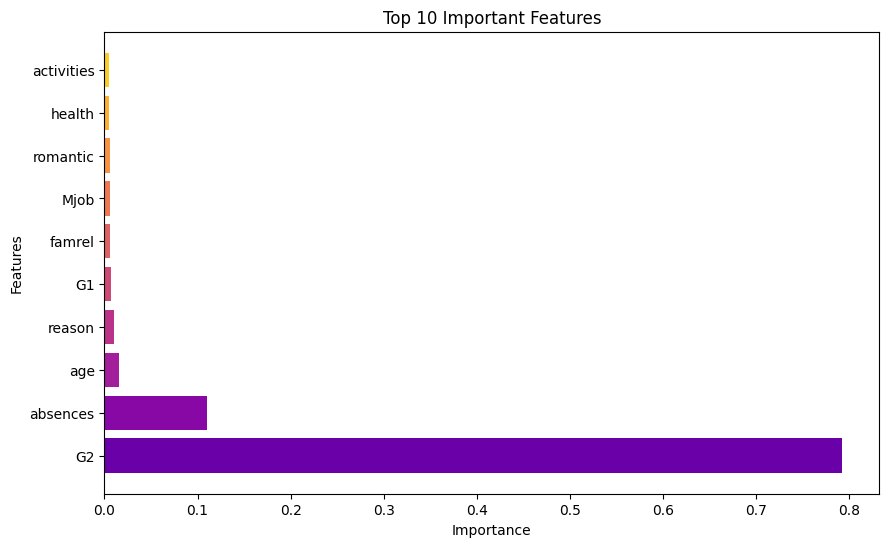

In [56]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(10)

colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(top_features)))

plt.barh(
    top_features['Feature'],
    top_features['Importance'],
    color=colors
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.show()

# Task 8: Model Deployment

## Future Scope

The trained Random Forest model can be deployed using Streamlit or Flask to create a web application for student grade prediction.

Deployment was not implemented in the current project and can be considered as future work.

# Conclusion

The Student Performance Dataset was analyzed using Data Science techniques. Data preprocessing, exploratory data analysis, feature engineering, model building, and model evaluation were successfully completed.

The Random Forest Regressor achieved an R² score of approximately 0.83, indicating strong predictive performance. Feature importance analysis revealed that previous academic performance was the most significant factor influencing final grades.

This project demonstrates the practical application of Data Science and Machine Learning techniques for predictive analytics.